# Explaining Machine Learning Predictions Using SHAP

## Objective
This notebook demonstrats how SHAP (Shapley Additive Explanations) can be used to explain the predictions of a Random Forest classifier on the Breast Cancer Wisconsin dataset.

## AIM
The main goal is not only to build a predictive model but also to understand **why** the model makes its decisions by analysing feature contributions at both global and local levels.

## Link to Github repo: https://github.com/shaikmahaboobsharief7/shap-model-explainability-breast-cancer.git

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)
import warnings
warnings.filterwarnings("ignore")

In [20]:
file_path = "data.csv"

df = pd.read_csv(file_path)
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [21]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Data types:
id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimen

### Data Cleaning

Two columns were removed during preprocessing:

- **`id`**: This column is a unique identifier for each sample and does not contain any predictive information. Including it would not improve model performance and can introduce noise.

- **`Unnamed: 32`**: This column contains only missing values and does not represent any meaningful importance.

Removing these columns ensures that the model is trained only on meaningful and relevant data.

In [ ]:
drop_cols = [col for col in ["id", "Unnamed: 32"] if col in df.columns]
df = df.drop(columns=drop_cols)

print("Shape after dropping unwanted columns:", df.shape)
df.head()

Shape after dropping unwanted columns: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [23]:
print(df["diagnosis"].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


### Feature and Target Separation

The dataset is divided into:

- **Features (X)**: all input variables used to make predictions  
- **Target (y)**: the diagnosis column representing tumour classification  

The target variable is encoded as:
- 1 = Malignant  
- 0 = Benign  

The dataset contains 569 samples with 30 features. The class distribution shows a higher number of benign cases compared to malignant cases, indicating a slight class imbalance.

In [24]:
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

print(df["diagnosis"].value_counts())
df.head()

diagnosis
0    357
1    212
Name: count, dtype: int64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [25]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("First 5 feature names:")
print(X.columns[:5].tolist())

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (569, 30)
Target shape: (569,)
First 5 feature names:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']

Target distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


## Model Training and Evaluation

### Train-Test Split

The dataset is divided into training and testing sets:

- **Training set (80%)**: used to train the model  
- **Test set (20%)**: used to evaluate performance  

Stratified sampling is used to maintain the same proportion of malignant and benign cases in both sets.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Train distribution:\n", y_train.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))

Training set: (455, 30)
Test set: (114, 30)
Train distribution:
 diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Test distribution:
 diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


### Random Forest Model

A Random Forest classifier is used as the predictive model.

It works by combining multiple decision trees to improve accuracy and reduce overfitting. Each tree learns different patterns from the data and the final prediction is based on the aggregation of all trees.

In [27]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [28]:
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

print(classification_report(y_test, y_pred))

Accuracy: 0.9737
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



### Model Performance

The Random Forest classifier achieved an accuracy of **97.37%** this indicating strong predictive performance on the test set.

The classification report shows that the model performs very well for both classes:

- Class **0 (Benign)** has perfect recall, meaning all benign cases were correctly identified.
- Class **1 (Malignant)** has perfect precision and high recall indicating that malignant cases are predicted correctly with very few false negatives.

Overall the model demonstrates strong classification capability and is suitable for further explainability analysis using SHAP.

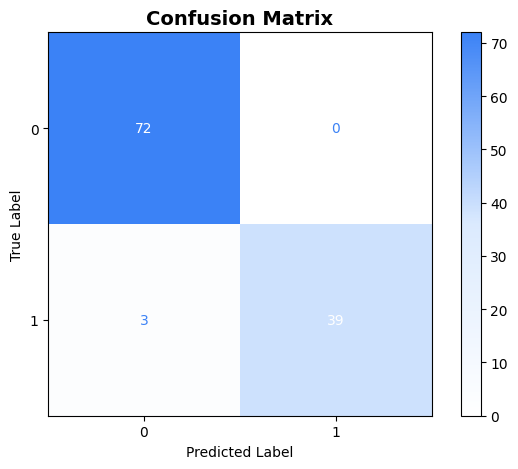

In [ ]:

blue_cmap = LinearSegmentedColormap.from_list(
    "custom_blue",
    ["#ffffff", "#dbeafe", "#3b82f6"]
)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=blue_cmap, values_format="d")

plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the model correctly classified all 72 benign cases and 39 out of 42 malignant cases.

There are no false positives meaning no benign cases were incorrectly predicted as malignant. However, there are 3 false negatives where malignant cases were predicted as benign. In medical domain false negatives are particularly important because they may delay diagnosis and treatment.

Overall the confusion matrix indicates strong performance while also highlighting the importance of carefully analysing errors in healthcare-related predictions.

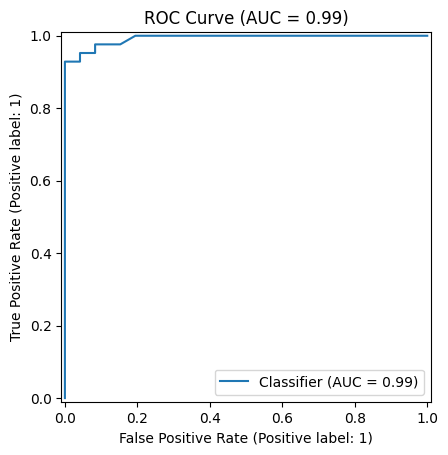

In [30]:
roc_auc = roc_auc_score(y_test, y_proba)

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.show()

### ROC Curve Interpretation

The ROC curve evaluates the model’s ability to distinguish between malignant and benign tumours across different decision thresholds.

An AUC of 0.99 indicates near-perfect ability to rank malignant cases above benign ones. Yet even here excellence is not transparency we still cannot explain why the model is right or diagnose why it occasionally fails.

## Why Explainability is Important

Machine learning models can achieve high accuracy but they often operate as black boxes.

In critical domains such as healthcare it is not enough to make accurate predictions it is essential to understand why a prediction is made.

Without explainability:
- models cannot be trusted
- errors cannot be analysed properly
- decision-making lacks transparency

This motivates the use of SHAP to interpret model predictions.

### SHAP and Game Theory

SHAP is based on Shapley values from cooperative game theory.

Each feature is treated as a “player” contributing to the final prediction.

The Shapley value represents the average contribution of a feature across all possible combinations of features.

This ensures:
- fairness
- consistency
- interpretability

This makes SHAP one of the most theoretically sound explainability methods.

### Model Explainability with SHAP

In [ ]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

class_index = 1
shap_values_for_plot = shap_values[:, :, class_index]
base_value = explainer.expected_value[class_index]

print("Type of SHAP values:", type(shap_values))
print("Full SHAP shape:", np.array(shap_values).shape)
print("Class-specific SHAP shape:", np.array(shap_values_for_plot).shape)
print("Base value:", base_value)

Type of SHAP values: <class 'numpy.ndarray'>
Full SHAP shape: (114, 30, 2)
Class-specific SHAP shape: (114, 30)
Base value: 0.3725934065934068


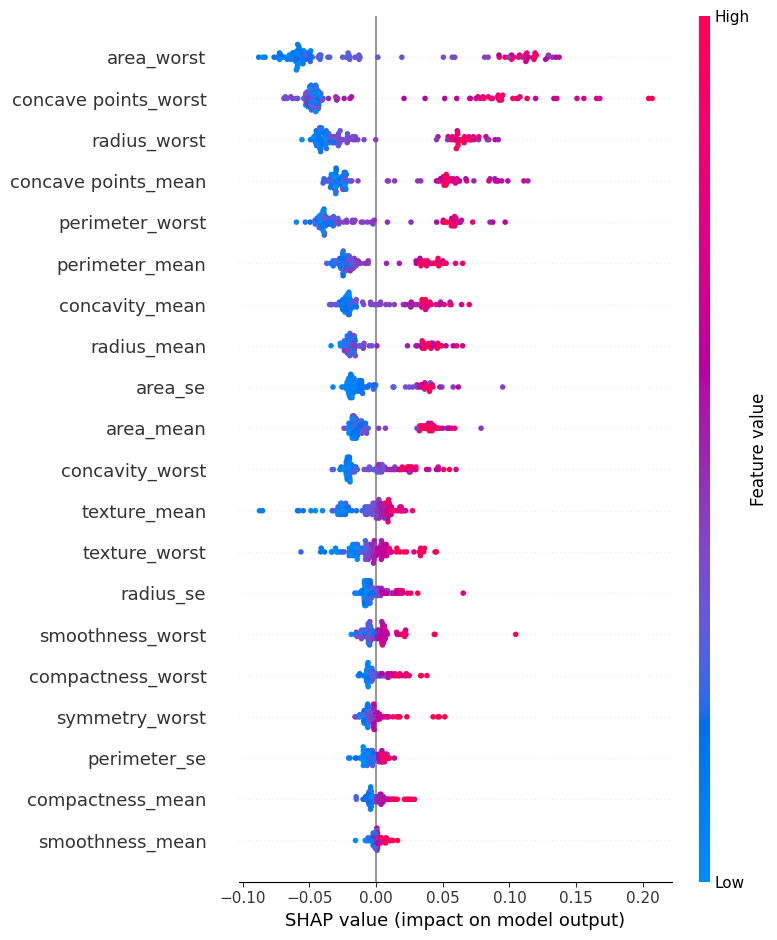

In [32]:
plt.figure()
shap.summary_plot(shap_values_for_plot, X_test, show=False)
plt.tight_layout()
plt.show()

### SHAP Summary Plot

The SHAP summary plot shows the overall importance of each feature across the test dataset.

- Features at the top have the greatest influence on model predictions.
- Each dot represents one observation.
- The colour shows whether the feature value is high or low.
- The horizontal position shows whether the feature pushes the prediction toward malignant or benign.

This helps identify which tumour characteristics are most influential in the models decision-making process.

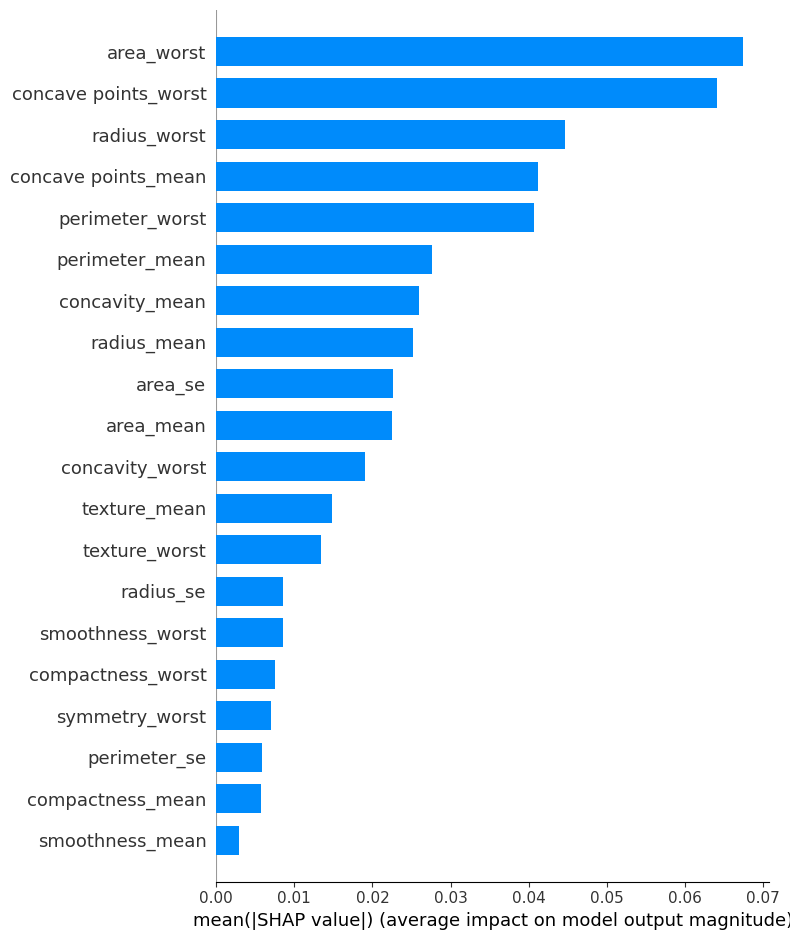

In [33]:
plt.figure()
shap.summary_plot(shap_values_for_plot, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

### Bar Plot Interpretation

The bar plot shows the average absolute contribution of each feature to the model predictions.

Features such as **area_worst**, **concave points_worst**, and **radius_worst** have the highest impact indicating that tumour size and shape irregularity are key factors in determining malignancy.

This aligns with domain knowledge as larger and more irregular tumour shapes are typically associated with higher cancer risk.

### SHAP vs Traditional Feature Importance

Traditional feature importance shows which features are important overall but does not explain individual predictions.

SHAP provides:
- global explanations (feature importance)
- local explanations (individual predictions)

This makes SHAP significantly more powerful for understanding model behaviour.

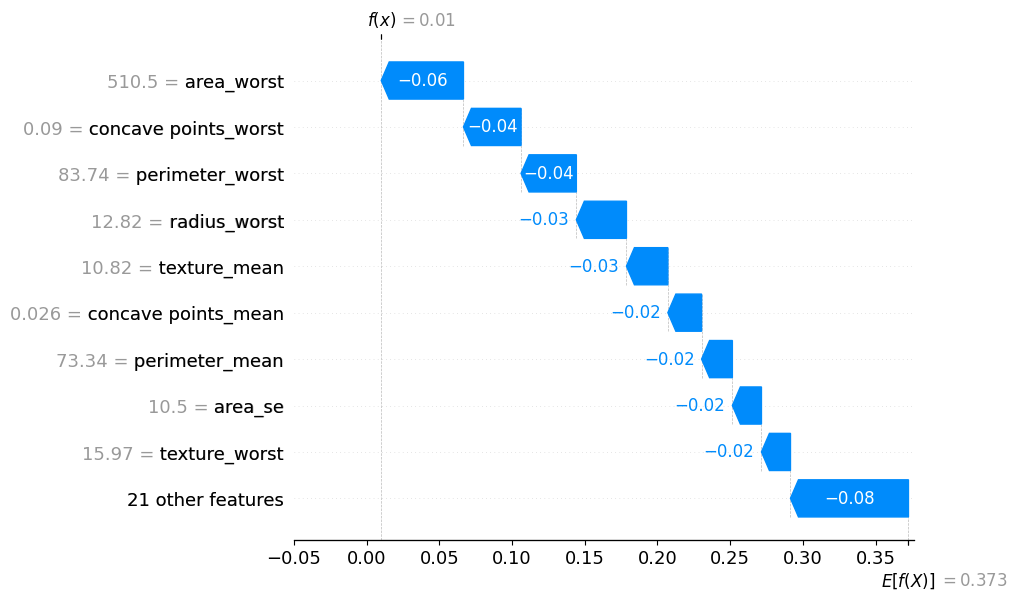

In [34]:
sample_index = 0

single_shap_values = shap_values_for_plot[sample_index]

shap_explanation = shap.Explanation(
    values=single_shap_values,
    base_values=base_value,
    data=X_test.iloc[sample_index].values,
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(shap_explanation)

### Interpretation

For this patient, the model predicts the tumour as benign.

Key features such as lower area_worst and concave points_worst reduce the probability of malignancy.

This aligns with medical understanding, where smaller and less irregular tumours are typically non-cancerous.

This demonstrates how SHAP explanations can support real-world medical decision-making.

### Local Explanation of an Waterfall Plot

The SHAP waterfall plot explains how each feature contributes to the prediction for a single test instance.

The model starts from a baseline probability and adjusts this based on feature contributions. Features shown in blue decrease the probability of malignancy, while those in red increase it.

For this sample the final predicted probability of malignancy is very low (≈ 0.01) indicating that the tumour is likely benign. Key features such as **area_worst**, **concave points_worst**, and **radius_worst** contribute negatively, pushing the prediction away from malignancy.

This demonstrates how SHAP provides transparency by clearly showing how individual features influence the model’s decision.

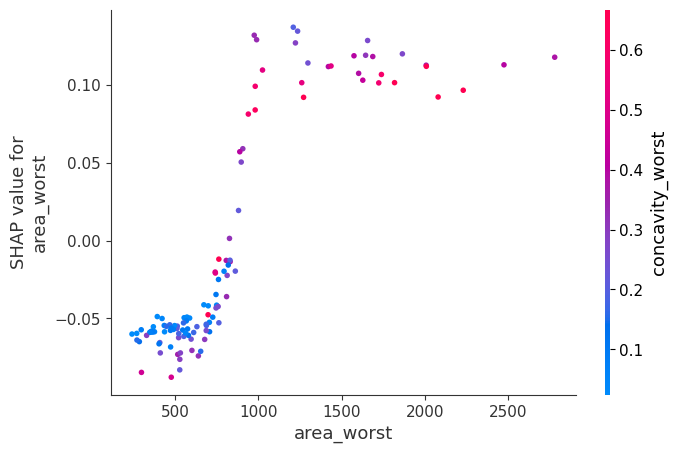

In [35]:
shap.dependence_plot("area_worst", shap_values_for_plot, X_test)

### Dependence Plot Interpretation:

The SHAP dependence plot shows how the value of a specific feature affects the model prediction.

For example, higher values of **area_worst** are associated with a higher likelihood of malignancy. This indicates that larger tumour areas significantly increase the probability of cancer.

The plot also highlights interactions between features providing deeper insight into how the model uses feature values to make predictions.

### Before vs After Explainability

Before using SHAP, the model behaves as a black box where we only know the final prediction and accuracy.

After applying SHAP, we gain full visibility into:
- which features influence predictions
- how each feature contributes
- why a specific prediction is made

This transformation turns the model from a black box into an interpretable system.

### Key Insights

The Random Forest model achieved high predictive accuracy, but accuracy alone does not explain how decisions are made.

SHAP analysis revealed that features related to tumour size and shape such as **area_worst**, **concave points_worst**, and **radius_worst**, have the greatest influence on predictions.

This demonstrates that the model relies on clinically meaningful features increasing confidence in its predictions.

The ability to explain individual predictions using SHAP provides transparency and supports the use of machine learning in sensitive domains such as healthcare.

### Limitations of SHAP

Although SHAP is powerful, it has some limitations.

It can be computationally expensive for large datasets and complex models. Additionally, interpreting SHAP plots can become challenging when dealing with many features.

Despite these limitations, SHAP remains one of the most reliable methods for model explainability.

### Conclusion

This tutorial demonstrated how SHAP can be used to explain machine learning predictions.

While the Random Forest model provides strong predictive performance, SHAP enables deeper understanding by quantifying the contribution of each feature.

This combination of accuracy and interpretability is essential for deploying machine learning models in real-world applications.

### Personal Reflection

Understanding SHAP significantly improved my ability to interpret machine learning models.

Rather than treating models as black boxes I can now analyse how individual features influence predictions which is especially important in real-world applications such as healthcare.